In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e12/sample_submission.csv
/kaggle/input/playground-series-s5e12/train.csv
/kaggle/input/playground-series-s5e12/test.csv


# Introduction

The perpose of this notebook is set up a easy and readable solution. If time allows I will try to improve performance.

This notebook include step by step thought process. It's to help me to improve over time.

1. Load and explore data
2. Data visualization
3. Preprocess and clean data
4. Choose the right model
5. Tune and Optimize
6. Deploy the model and submit the result

In [2]:
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.model_selection import StratifiedKFold
# config
#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
#print(device)
class CFG:
    train_csv = '/kaggle/input/playground-series-s5e12/train.csv'
    test_csv = '/kaggle/input/playground-series-s5e12/test.csv'
    sample_submission_csv = '/kaggle/input/playground-series-s5e12/sample_submission.csv'
    N_FOLDS = 5
    RANDOM_SEED = 42

# Load and explore data

In [3]:
train = pd.read_csv(CFG.train_csv)
test = pd.read_csv(CFG.test_csv)
sample_submission = pd.read_csv(CFG.sample_submission_csv)

In [4]:
print("------------train data------------")
print(train.shape)
print(train.head())
print("------------test data------------")
print(test.shape)
print(test.head())

------------train data------------
(700000, 26)
   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day   bmi  \
0         7.7                  6.8                        6.1  33.4   
1         5.7                  6.5                        5.8  23.8   
2         8.5                  7.4                        9.1  24.1   
3         4.6                  7.0                        9.2  26.6   
4         5.7                  6.2                        5.1  28.8   

   waist_to_hip_ratio  systolic_bp  ...  gen

In [5]:
# basic statistics
print(train.describe())

                  id            age  alcohol_consumption_per_week  \
count  700000.000000  700000.000000                 700000.000000   
mean   349999.500000      50.359734                      2.072411   
std    202072.738554      11.655520                      1.048189   
min         0.000000      19.000000                      1.000000   
25%    174999.750000      42.000000                      1.000000   
50%    349999.500000      50.000000                      2.000000   
75%    524999.250000      58.000000                      3.000000   
max    699999.000000      89.000000                      9.000000   

       physical_activity_minutes_per_week     diet_score  sleep_hours_per_day  \
count                       700000.000000  700000.000000        700000.000000   
mean                            80.230803       5.963695             7.002200   
std                             51.195071       1.463336             0.901907   
min                              1.000000       0.1000

I can tell from the describe above that some of the data is already tranform into numeric data.

family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes

And the data we need to predict is already encode into numeric data(1,0).

In [6]:
# check if there is any nan data in it
train.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


# Data Visualization

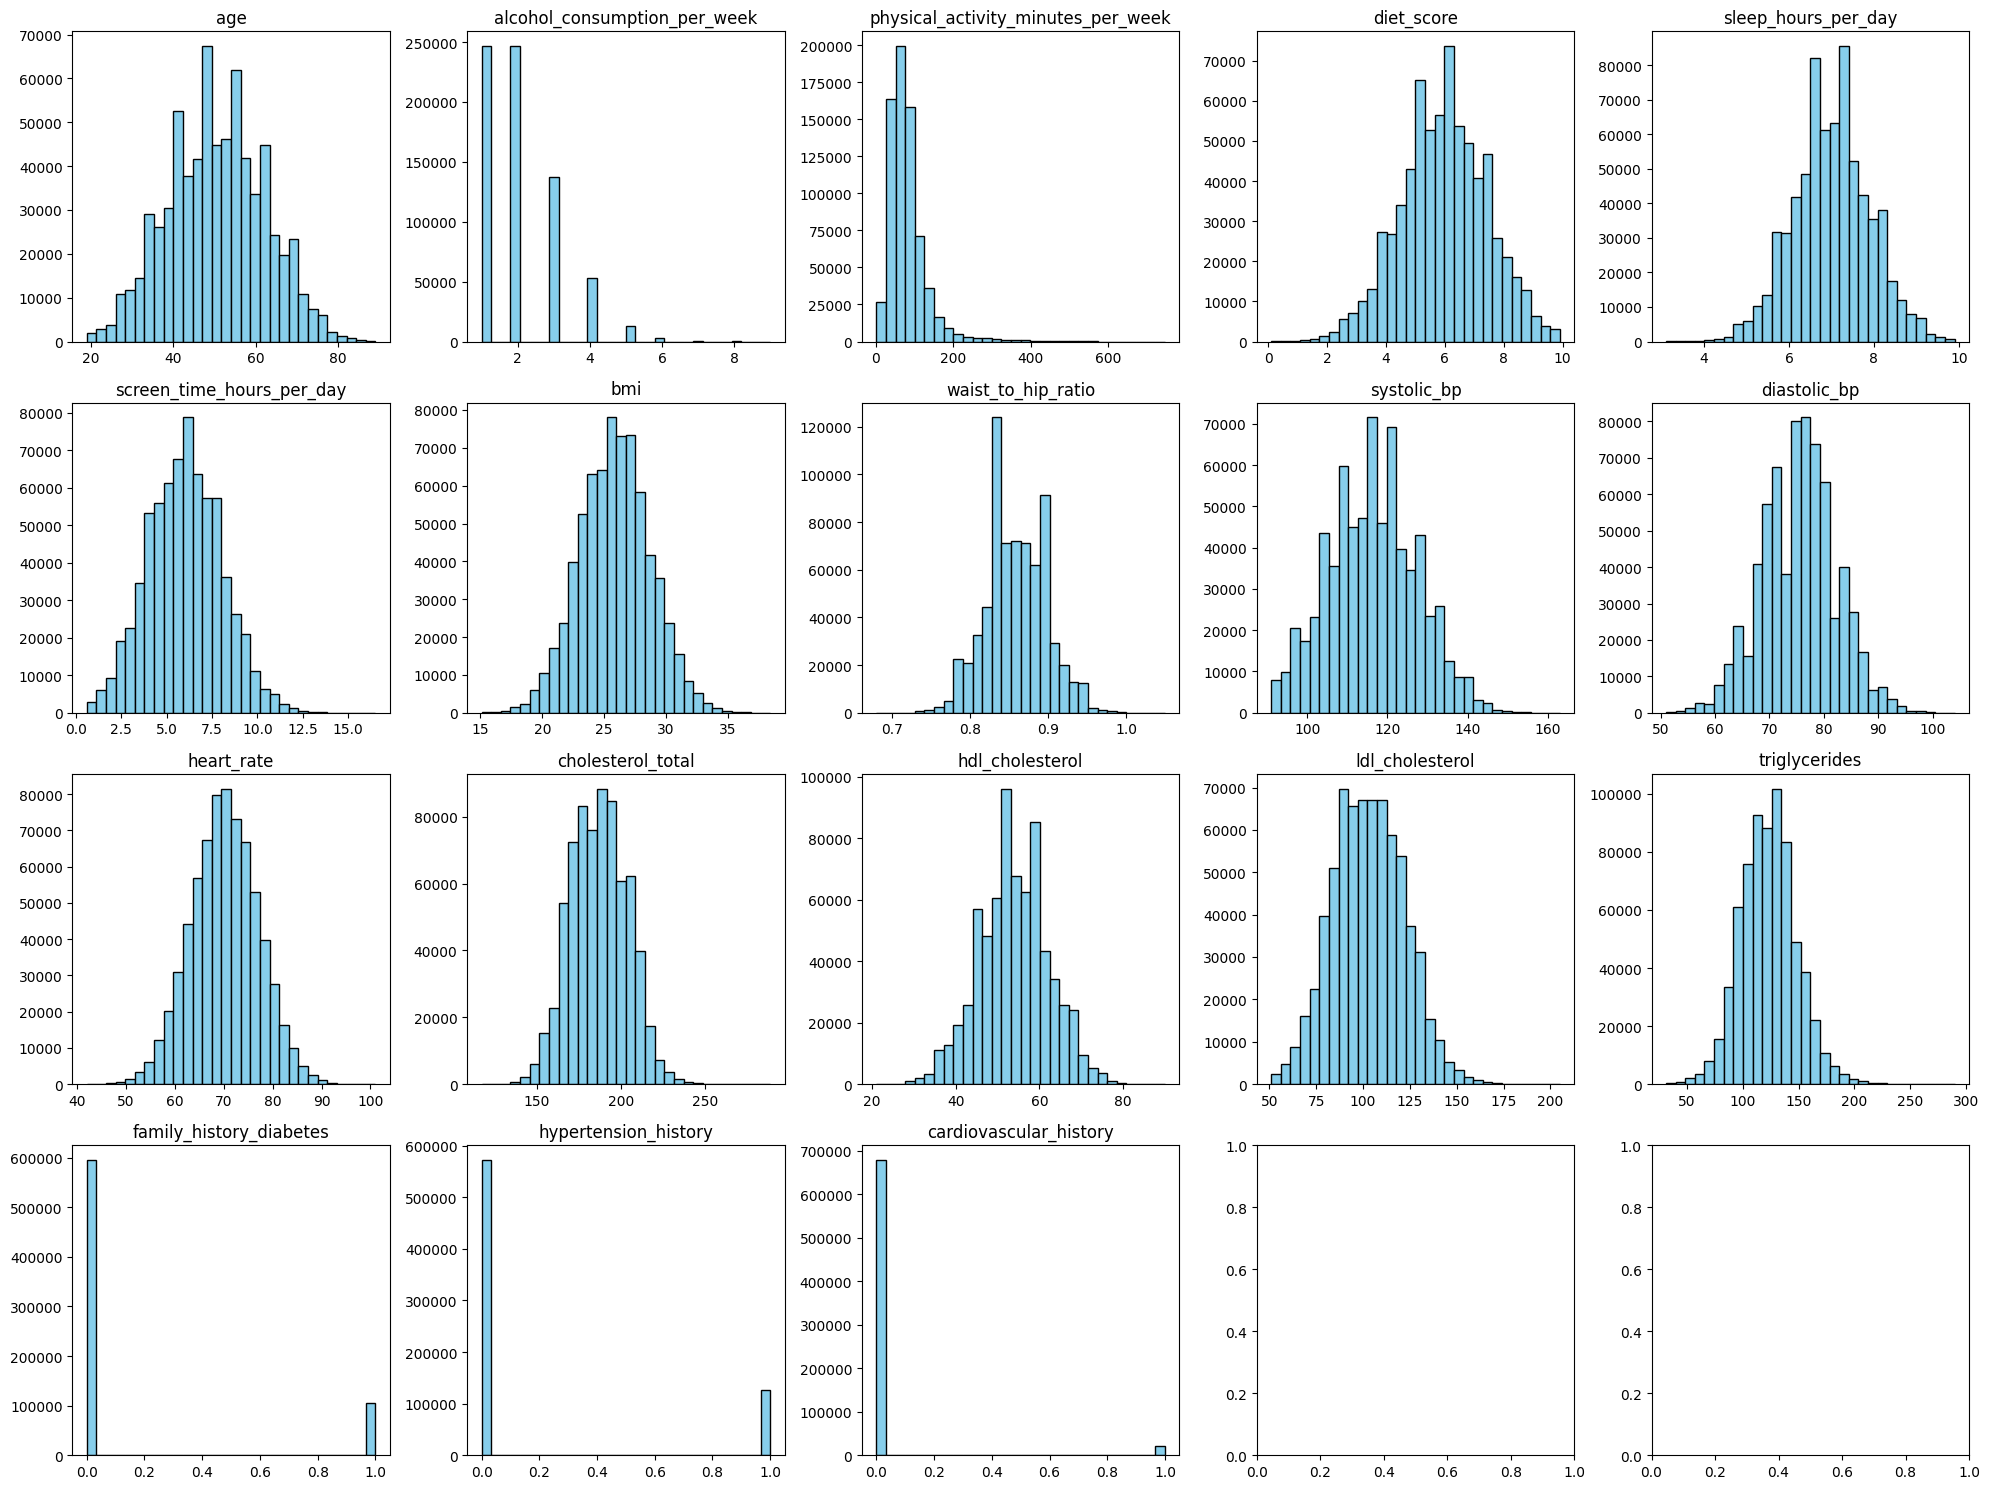

In [7]:
numeric_cols = train.columns[train.dtypes.apply(lambda x: np.issubdtype(x, np.number))].tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id', 'diagnosed_diabetes']]

fig, axs = plt.subplots(4, 5, figsize=(20, 15)) # Adjust grid size as needed
axs = axs.flatten() # Flattens the 2D grid to 1D

for i, col in enumerate(numeric_cols):
    if i < len(axs):
        axs[i].hist(train[col], bins=30, color='skyblue', edgecolor='black')
        axs[i].set_title(col)
    else:
        axs[i].axis('off') # Hide unused subplots

plt.tight_layout()
plt.show()

From the figure above you can tell that most of the data is normal distribution. So I think there is no significant outlier in the data.

But as my previous experience about predicting health problem, family history about relate disease play an import part about the result.

Therefore, I may need to further examine the importance of each data point in the model.

# Encode the data

In [8]:
# we use "Label Encodeing" because its simple to set up
# gender,ethnicity,education_level,income_level,smoking_status,employment_status

encoder = LabelEncoder()
gender_encoded = encoder.fit_transform(train["gender"])
ethnicity_encoded = encoder.fit_transform(train["ethnicity"])
education_level_encoded = encoder.fit_transform(train["education_level"])
income_level_encoded = encoder.fit_transform(train["income_level"])
smoking_status_encoded = encoder.fit_transform(train["smoking_status"])
employment_status_encoded = encoder.fit_transform(train["employment_status"])

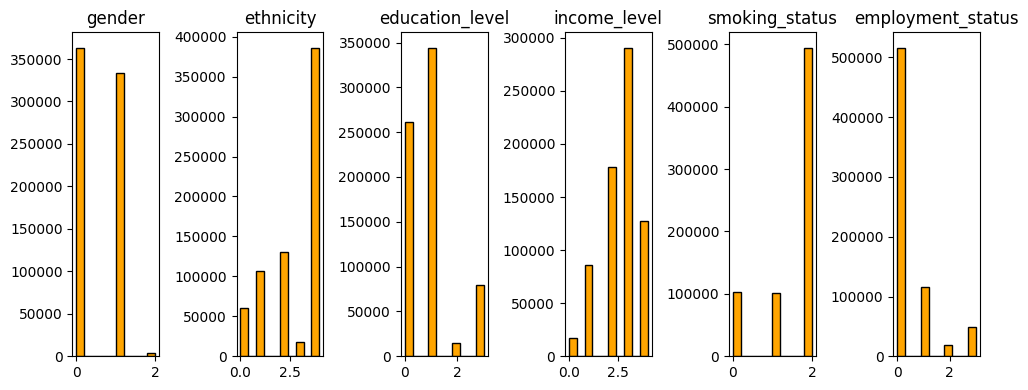

In [9]:
# Create subplots
fig, axs = plt.subplots(1, 6, figsize=(10, 4))  # 1 row, 4 columns
axs[0].hist(gender_encoded, color='orange', edgecolor='black')
axs[0].set_title('gender')
axs[1].hist(ethnicity_encoded, color='orange', edgecolor='black')
axs[1].set_title('ethnicity')
axs[2].hist(education_level_encoded, color='orange', edgecolor='black')
axs[2].set_title('education_level')
axs[3].hist(income_level_encoded,color='orange', edgecolor='black')
axs[3].set_title('income_level')
axs[4].hist(smoking_status_encoded, color='orange', edgecolor='black')
axs[4].set_title('smoking_status')
axs[5].hist(employment_status_encoded, color='orange', edgecolor='black')
axs[5].set_title('employment_status')
plt.tight_layout()
plt.show()

For now I have no idea how to look into this data.

**I wil change this after I do some research.**

# Preprocess and clean data

**Why use a Class?**

State Retention: You need to remember the median values and the Encoders from the Training set so you can apply exactly the same rules to the Test set.


Avoids Leakage: Your previous function calculated the median of the test set using the test set. In a real scenario, you must use the training set's median to fill the test set.


Handles Unknowns: I replaced LabelEncoder with OrdinalEncoder. LabelEncoder crashes if the Test set has a category not seen in Train. OrdinalEncoder can be configured to handle these safely.

In [10]:
class DiabetesPreprocessor:
    def __init__(self):
        self.medians = {}
        self.encoders = {}
        self.numeric_cols = []
        self.categorical_cols = []
        
    def fit(self, df):
        """
        Learn the parameters (medians, categories) from the TRAINING data.
        """
        # Identify columns
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
        
        # 1. Learn Medians for numeric columns
        for col in self.numeric_cols:
            self.medians[col] = df[col].median()
            
        # 2. Fit Encoders for categorical columns
        # handle_unknown='use_encoded_value' prevents crashes if Test data has new categories
        for col in self.categorical_cols:
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            # We must reshape to (-1, 1) for sklearn encoders
            enc.fit(df[[col]].astype(str)) 
            self.encoders[col] = enc
            
        return self

    def transform(self, df):
        """
        Apply the learned parameters to the data (Train or Test).
        """
        df = df.copy()
        
        # 1. Drop irrelevant columns (ID is usually dropped, Target handled separately)
        # Note: We don't drop target here to keep X and y aligned until the end
        if 'id' in df.columns:
            df = df.drop(columns=['id'])
            
        # 2. Impute Missing Values using LEARNED medians
        for col in self.numeric_cols:
            if col in df.columns:
                df[col] = df[col].fillna(self.medians.get(col, 0))
        
        # 3. Apply Encoding
        for col in self.categorical_cols:
            if col in df.columns:
                # Fill NaN in categoricals with 'Missing' before encoding to be safe
                df[col] = df[col].astype(str).fillna('Missing')
                df[col] = self.encoders[col].transform(df[[col]])
        
        # 4. Feature Engineering (Domain Specific)
        # Replacing your "Loan" features with Diabetes features
        
        # BMI is often more useful than just weight/height
        if 'weight' in df.columns and 'height' in df.columns:
             # Assuming height might be in cm, convert to meters if needed. 
             # If height is already M, remove the /100
            df['bmi_calc'] = df['weight'] / ((df['height']/100) ** 2)
        
        # Interaction: Age and Glucose levels are often correlated with risk
        if 'age' in df.columns and 'glucose_levels' in df.columns:
            df['age_glucose_interaction'] = df['age'] * df['glucose_levels']
            
        return df

In [11]:
# Initialize the preprocessor
preprocessor = DiabetesPreprocessor()

# Separate Target from Train for fitting (optional, but cleaner)
# It is best to calculate stats on the features, not including the target
X_train_raw = train.drop(columns=['diagnosed_diabetes'])
y_train = train['diagnosed_diabetes']
test_ids = test['id']

# FIT on Training Data Only (Learn the rules)
preprocessor.fit(X_train_raw)

# TRANSFORM both Train and Test (Apply the rules)
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(test)

In [12]:
X_train_processed.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,102,0.0,2.0,1.0,2.0,0.0,0.0,0,0,0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,124,0.0,4.0,1.0,4.0,2.0,0.0,0,0,0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,108,1.0,2.0,1.0,2.0,2.0,1.0,0,0,0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,123,0.0,4.0,1.0,2.0,0.0,0.0,0,1,0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,124,1.0,4.0,1.0,4.0,2.0,1.0,0,1,0


# Train model

# Hyper parameter with OPTUNA

2025/12/08 change it into Kfold

In [13]:
X_tuning, _, y_tuning, _ = train_test_split(
    X_train_processed, y_train, 
    train_size=0.4, # Tune on 40% of data
    stratify=y_train, 
    random_state=42
)

# Define the number of folds
def objective_cv(trial, X, y, n_folds=CFG.N_FOLDS, random_seed=CFG.RANDOM_SEED):
    """
    Optuna objective function that uses Stratified K-Fold Cross-Validation.
    """
    # 1. Define Hyperparameters using Optuna trial suggestions
    param = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "use_label_encoder": False,
        "tree_method": 'hist', # Faster training method
        "booster": 'gbtree',
        "random_state": random_seed,
        
        # Hyperparameters to tune
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True), # Use log scale for LR
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
    }

    # 2. Setup Stratified K-Fold
    # Ensure stable splits regardless of data size
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
    auc_scores = []
    
    # 3. Training Loop (Cross-Validation)
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Instantiate and train model
        model = xgb.XGBClassifier(**param)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predict probabilities and calculate AUC for this fold
        y_pred_prob = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred_prob)
        auc_scores.append(auc)
        
    # 4. Return the mean AUC across all folds
    mean_auc = np.mean(auc_scores)
    #Print the result for the current trial
    print(f"Trial {trial.number:3d} finished with mean CV AUC: {mean_auc:.6f}")
    
    return mean_auc


train_x = X_train_processed 
train_y = y_train 
# Build and run Optuna study
print("Starting Optuna study with Stratified K-Fold...")
study = optuna.create_study(direction="maximize")  # Maximize the mean AUC
# Pass the full training data (X and y) to the objective function
study.optimize(lambda trial: objective_cv(trial, X_tuning, y_tuning), n_trials=20)
print("Study complete.")

# Result
print("\n🎉 Best parameters found by CV Optuna:")
print(study.best_params)
print(f"Best Mean CV AUC: {study.best_value:.4f}")

[I 2025-12-08 15:50:40,590] A new study created in memory with name: no-name-5f727cd9-7d7b-4cc7-8269-3f13e92a5b58


Starting Optuna study with Stratified K-Fold...


[I 2025-12-08 15:52:07,103] Trial 0 finished with value: 0.7127529991367595 and parameters: {'max_depth': 10, 'learning_rate': 0.06936368391558581, 'n_estimators': 400, 'subsample': 0.7018951197955093, 'colsample_bytree': 0.6085525126216192, 'min_child_weight': 1, 'gamma': 1.101510705347708e-06, 'reg_alpha': 0.01251616037785931, 'reg_lambda': 0.5886789963327048}. Best is trial 0 with value: 0.7127529991367595.


Trial   0 finished with mean CV AUC: 0.712753


[I 2025-12-08 15:52:40,609] Trial 1 finished with value: 0.706449936221207 and parameters: {'max_depth': 8, 'learning_rate': 0.011585794821495337, 'n_estimators': 150, 'subsample': 0.9925558974904576, 'colsample_bytree': 0.9792721491848612, 'min_child_weight': 4, 'gamma': 0.014997034478598476, 'reg_alpha': 1.2144876464352642e-06, 'reg_lambda': 6.765027460934299e-07}. Best is trial 0 with value: 0.7127529991367595.


...

Trial  17 finished with mean CV AUC: 0.721709


[I 2025-12-08 16:25:06,937] Trial 18 finished with value: 0.7219863652306044 and parameters: {'max_depth': 6, 'learning_rate': 0.04188672546960223, 'n_estimators': 550, 'subsample': 0.8297304008254588, 'colsample_bytree': 0.9299787907987095, 'min_child_weight': 5, 'gamma': 0.001901713117252024, 'reg_alpha': 0.01968746070877232, 'reg_lambda': 0.00022543107866502678}. Best is trial 16 with value: 0.7229531805523013.


Trial  18 finished with mean CV AUC: 0.721986


[I 2025-12-08 16:27:04,921] Trial 19 finished with value: 0.7226369913857379 and parameters: {'max_depth': 5, 'learning_rate': 0.03987546229769952, 'n_estimators': 850, 'subsample': 0.840715238864389, 'colsample_bytree': 0.9956680067748699, 'min_child_weight': 3, 'gamma': 0.8663721070157994, 'reg_alpha': 0.01376548097865854, 'reg_lambda': 0.027682086014166614}. Best is trial 16 with value: 0.7229531805523013.


Trial  19 finished with mean CV AUC: 0.722637
Study complete.

🎉 Best parameters found by CV Optuna:
{'max_depth': 5, 'learning_rate': 0.039074227437586595, 'n_estimators': 1000, 'subsample': 0.8381531225372353, 'colsample_bytree': 0.9044754927043669, 'min_child_weight': 6, 'gamma': 0.0018238576553199462, 'reg_alpha': 0.016772882494894815, 'reg_lambda': 2.1138734413918467e-05}
Best Mean CV AUC: 0.7230


# Submission

In [14]:
# Final Model Training (Retrain on ALL Training Data)
# Once the best hyperparameters are found, we train the final model 
# on the ENTIRE training set (train_x and train_y) for maximum data utilization.
best_params = study.best_params

final_model = xgb.XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="auc",
    use_label_encoder=False,
    tree_method='hist',
    random_state=CFG.RANDOM_SEED
)

# Train on the full, processed training set
final_model.fit(train_x, train_y) 

# 3. Generate predictions for the submission file
# Use your processed test data (X_test_processed)
y_pred_prob_final = final_model.predict_proba(X_test_processed)[:, 1]

# 4. Submission file prepare
# IMPORTANT: Ensure the column name is 'diagnosed_diabetes'
submission = pd.DataFrame({
    'id': test['id'],  # Use the original IDs from the test set
    'diagnosed_diabetes': y_pred_prob_final
})
submission.to_csv('cv_optuna_submission.csv', index=False, header=True)
print("\nSubmission file created: cv_optuna_submission.csv")

print(f"Submission file created: {submission.shape}")
print("First 5 rows of submission:")
print(submission.head())


Submission file created: cv_optuna_submission.csv
Submission file created: (300000, 2)
First 5 rows of submission:
       id  diagnosed_diabetes
0  700000            0.494412
1  700001            0.679835
2  700002            0.770380
3  700003            0.414114
4  700004            0.919837
